                                                                                            by Maria 

# <center> Traffic sign classification

In [1]:
import torch
print(torch.__version__)

2.5.1+cu124


In [23]:
pip install kagglehub

  Using cached kagglehub-0.3.4-py3-none-any.whl.metadata (22 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached kagglehub-0.3.4-py3-none-any.whl (43 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


# Задание 2 

In [1]:
from collections import Counter
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import torch
import torchvision
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from skimage.feature import hog
import time
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CyclicLR
from torchmetrics.functional import accuracy
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score


In [2]:
pip show torch

Name: torch
Version: 2.5.1+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: C:\Users\Daniil\myenv\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: torchaudio, torchmetrics, torchvision
Note: you may need to restart the kernel to use updated packages.


# 0. Исходные данные

Теперь давайте адаптируем написанную вами нейронку для решения других практических задач. 
Вам необходимо адаптировать её для задачи классификации дорожных знаков. Датасет состоит из 43 классов, все изображения имеют три канала.

**Датасет:** https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

### Подготовка данных:

1. **EDA** Для начала вам нужно исследовать датасет (EDA) и убедиться, что он хорошо сбалансирован – то есть в каждом классе одинаковое число изображений. 

2. **Балансировка данных:** Для балансировки вы можете использовать различные подходы для аугментации данных. Часть из них приведена здесь: https://pytorch.org/vision/main/transforms.html. Можете взять несколько из них, например:

      1. `RandomRotation`
      2. `RandomAffine`
      3. `ColorJitter`
      4. `GaussianBlur`
      5. `GaussianNoise`
      6. `adjust_brightness`
      7. `adjust_saturation`
      8. `adjust_hue`
    
3. Вы можете использовать любые из списка выше или по приведенной ссылке. В данном случае вы можете самостоятельно решить внутри команды кто какие виды аугментации делает и как это повлияет на производительность нейронки. Задокументируйте ваши решения и представьте на слайдах в презентации.

### Архитектура нейронной сети:

   В данном задании скорее всего LeNet-5 не сможет выдать достаточно хорошие метрики для классификации изображений. Поэтому вам необходимо будет попробовать несколько подходов для модификации архитектуры:
    
    1. Увеличить количество свёрточных блоков (convolution+pooling+activation).
    2. Добавить новые слои в свёрточные блоки (batch normalization, dropout).
    3. Попробовать использовать другие типы активационных функций (tanh, sigmoid, ReLU, LeakyReLU).
    4. Радикальный подход – используйте полностью другую архитектуру. AlexNet вытянет эту задачу намного лучше, чем LeNet.

Выберите внутри команды, кто и какие гипотезы проверяет на этапе подготовки архитектуры. Задокументируйте это и представьте на слайдах в презентации.

### Тренировка:
    
Во время тренировки вы можете модифицировать множество параметров для того, чтобы добиться необходимых результатов. 
1.	Количество эпох для обучения, learning rate, batch size.
2.	Типы оптимизаторов (Adam, SGD и прочие)
3.	Типы loss-функций (Cross-entropy, Log-likelihood и прочие)

### Метрики:
    
Для классификации будем использовать одну метрику – Accuracy. Значение Baseline для данной метрики сильно зависит от задачи. Например, точность, с которой человек способен классифицировать дорожные знаки из данного датасета составляет ~97%. Ваша задача – добиться значения не менее 90%. Если ваша нейронка будет выдавать более 97% - попросим в Яндексе поставить её на все беспилотные автомобили =)


# 1. EDA 

In [3]:
import kagglehub
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Daniil\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


In [4]:
dataset_path = os.path.join(path, r"C:\Users\Daniil\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1")
  
files = os.listdir(dataset_path)
print("Files in dataset directory:", files)

Files in dataset directory: ['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [5]:
dataset_path

'C:\\Users\\Daniil\\.cache\\kagglehub\\datasets\\meowmeowmeowmeowmeow\\gtsrb-german-traffic-sign\\versions\\1'

In [6]:
df = pd.read_csv(os.path.join(dataset_path, "Train.csv"))
#df_path = os.path.join(dataset_path, "Train.csv")
df_test = pd.read_csv(os.path.join(dataset_path, "Test.csv"))
meta = pd.read_csv(os.path.join(dataset_path, "Meta.csv"))

print("Training dataset:")
print(df.head())

print("\nTest dataset:")
print(df_test.head())

print("\nMeta dataset:")
print(meta.head())

Training dataset:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  

Test dataset:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      

In [7]:
df_path = os.path.join(dataset_path, "Train.csv")
df_test_path = os.path.join(dataset_path, "Test.csv")

print("Training dataset path:")
print(df_path)

print("\nTest dataset path:")
print(df_test_path)

Training dataset path:
C:\Users\Daniil\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1\Train.csv

Test dataset path:
C:\Users\Daniil\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1\Test.csv


In [8]:
df

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png
...,...,...,...,...,...,...,...,...
39204,52,56,5,6,47,51,42,Train/42/00042_00007_00025.png
39205,56,58,5,5,51,53,42,Train/42/00042_00007_00026.png
39206,58,62,5,6,53,57,42,Train/42/00042_00007_00027.png
39207,63,69,5,7,58,63,42,Train/42/00042_00007_00028.png


In [9]:
df.columns

Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='object')

In [10]:
info_data = {
    'Признак': [],
    'Описание на русском': [],
    'Тип признака' : []
}

traffic_signs_about = {
    'Width' : 'Ширина изображения',
    'Height' : 'Высота изображения',
    'Roi.X1' : 'Левая верхняя координата X знака на изображении',
    'Roi.Y1' : 'Левая верхняя координата Y знака на изображении',
    'Roi.X2' : 'Правая нижняя координата X знака на изображении',
    'Roi.Y2' : 'Правая нижняя координата Y знака на изображении',
    'ClassId' : 'Класс предоставленного изображения',
    'Path' : 'Путь к предоставленному изображению'
}

types = {
    'Width' : 'Integer',
    'Height' : 'Integer',
    'Roi.X1' : 'Integer',
    'Roi.Y1' : 'Integer',
    'Roi.X2' : 'Integer',
    'Roi.Y2' : 'Integer',
    'ClassId' : 'Categorical',
    'Path' : 'Str - int'
}

for column in df.columns:
    info_data['Признак'].append(column)
    info_data['Описание на русском'].append(traffic_signs_about.get(column, ''))
    info_data['Тип признака'].append(types.get(column, ''))

info_df = pd.DataFrame(info_data)

In [11]:
pd.set_option('display.max_colwidth', None)
info_df

,Признак,Описание на русском,Тип признака
0,Width,Ширина изображения,Integer
1,Height,Высота изображения,Integer
2,Roi.X1,Левая верхняя координата X знака на изображении,Integer
3,Roi.Y1,Левая верхняя координата Y знака на изображении,Integer
4,Roi.X2,Правая нижняя координата X знака на изображении,Integer
5,Roi.Y2,Правая нижняя координата Y знака на изображении,Integer
6,ClassId,Класс предоставленного изображения,Categorical
7,Path,Путь к предоставленному изображению,Str - int


In [12]:
print(f"Размер данных: {df.shape}")

print("\nИнформация о признаках:")
print(df.info())

print("\nПропущенные значения:")
print(df.isnull().sum())

print(f"\nКоличество классов: {df['ClassId'].nunique()}")

print(f"\nУникальные классы: {df['ClassId'].unique()}")

Размер данных: (39209, 8)

Информация о признаках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
dtypes: int64(7), object(1)
memory usage: 2.4+ MB
None

Пропущенные значения:
Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64

Количество классов: 43

Уникальные классы: [20  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


## 1.1. Проверка баланса классов

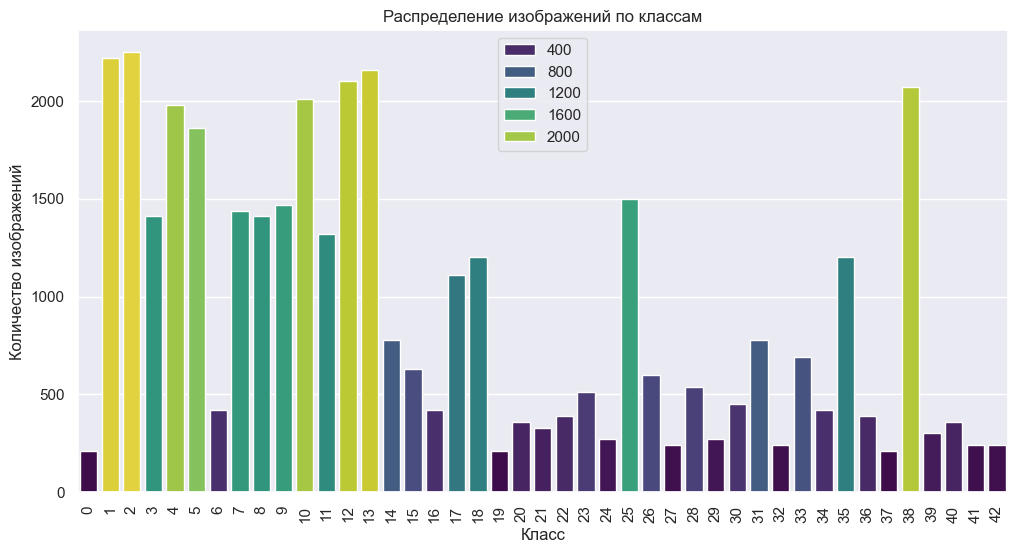

In [13]:
class_counts = df['ClassId'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(hue=class_counts.values , x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel("Класс")
plt.ylabel("Количество изображений")
plt.title("Распределение изображений по классам")
plt.xticks(rotation=90)
plt.show()

In [14]:
min_count = class_counts.min()
max_count = class_counts.max()
print(f"Минимум изображений в классе: {min_count}")
print(f"Максимум изображений в классе: {max_count}")

Минимум изображений в классе: 210
Максимум изображений в классе: 2250


Данные несбалансированы, требуется балансировка.


Статистика размеров изображений:
              Width        Height
count  39209.000000  39209.000000
mean      50.835880     50.328930
std       24.306933     23.115423
min       25.000000     25.000000
25%       35.000000     35.000000
50%       43.000000     43.000000
75%       58.000000     58.000000
max      243.000000    225.000000


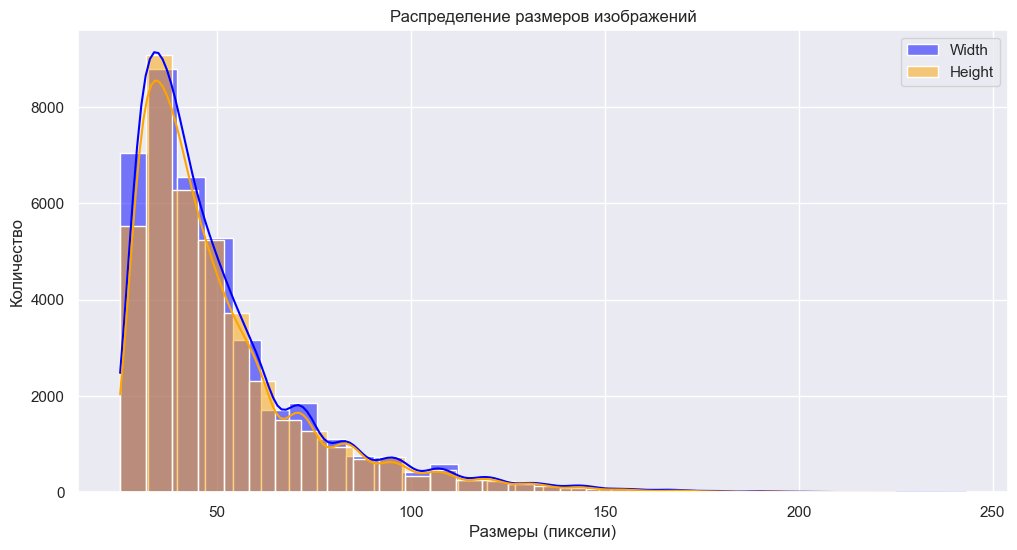

In [15]:
print("\nСтатистика размеров изображений:")
print(df[['Width', 'Height']].describe())

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Width', kde=True, color='blue', label='Width', bins=30)
sns.histplot(data=df, x='Height', kde=True, color='orange', label='Height', bins=30)
plt.legend()
plt.title("Распределение размеров изображений")
plt.xlabel("Размеры (пиксели)")
plt.ylabel("Количество")
plt.show()

In [16]:
duplicate_rows = df.duplicated()
num_duplicates = duplicate_rows.sum()
print(f"Количество дубликатов строк в DataFrame: {num_duplicates}")

Количество дубликатов строк в DataFrame: 0


In [17]:
def plot_random_images(df, base_path, n_samples=20, rows=4, cols=5):
    if n_samples > rows * cols:
        raise ValueError("The number of images exceeds the grid size.")
    plt.figure(figsize=(15, 10))

    for i, idx in enumerate(df.sample(n_samples).index):
        row = df.loc[idx] 
        image_path = os.path.join(base_path, row['Path'])
        try:
            image = Image.open(image_path)
            plt.subplot(rows, cols, i + 1)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"Class: {row['ClassId']}") 
        except FileNotFoundError:
            print(f"File {image_path} not found.")
            continue
        except Exception as e:
            print(f"Error processing image {image_path}: {e}")
            continue

    plt.tight_layout()
    plt.show()

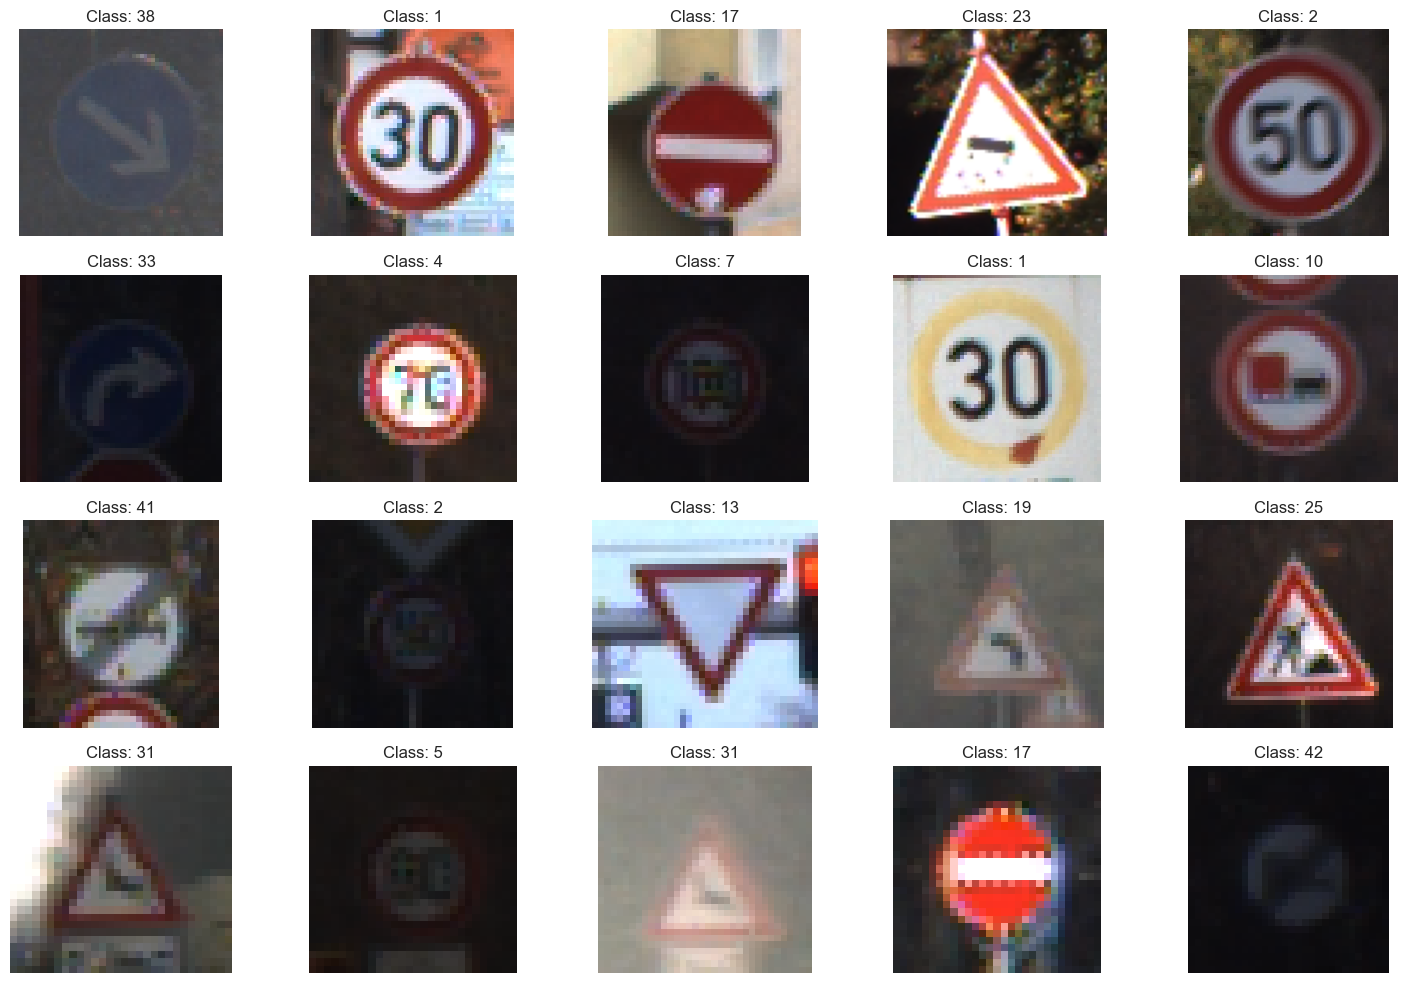

In [18]:
plot_random_images(df, dataset_path)

## 1.2. Визуализация ROI

In [19]:
def plot_sample_with_roi(df, base_path, n_samples=20, rows=4, cols=5):
    if n_samples > rows * cols:
        raise ValueError("Количество изображений превышает размер сетки.")
    plt.figure(figsize=(15, 10))
    
    for i, idx in enumerate(df.sample(n_samples).index):
        row = df.loc[idx]
        image_path = os.path.join(base_path, row['Path'])
        try:
            image = Image.open(image_path)
            image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
            
            roi_x1, roi_y1, roi_x2, roi_y2 = row['Roi.X1'], row['Roi.Y1'], row['Roi.X2'], row['Roi.Y2']
            
            cv2.rectangle(image, (roi_x1, roi_y1), (roi_x2, roi_y2), (255, 0, 0), 2)
            
            plt.subplot(rows, cols, i + 1)
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title(f"Class: {row['ClassId']}")
        except FileNotFoundError:
            print(f"Файл {image_path} не найден.")
            continue
    plt.tight_layout()
    plt.show()

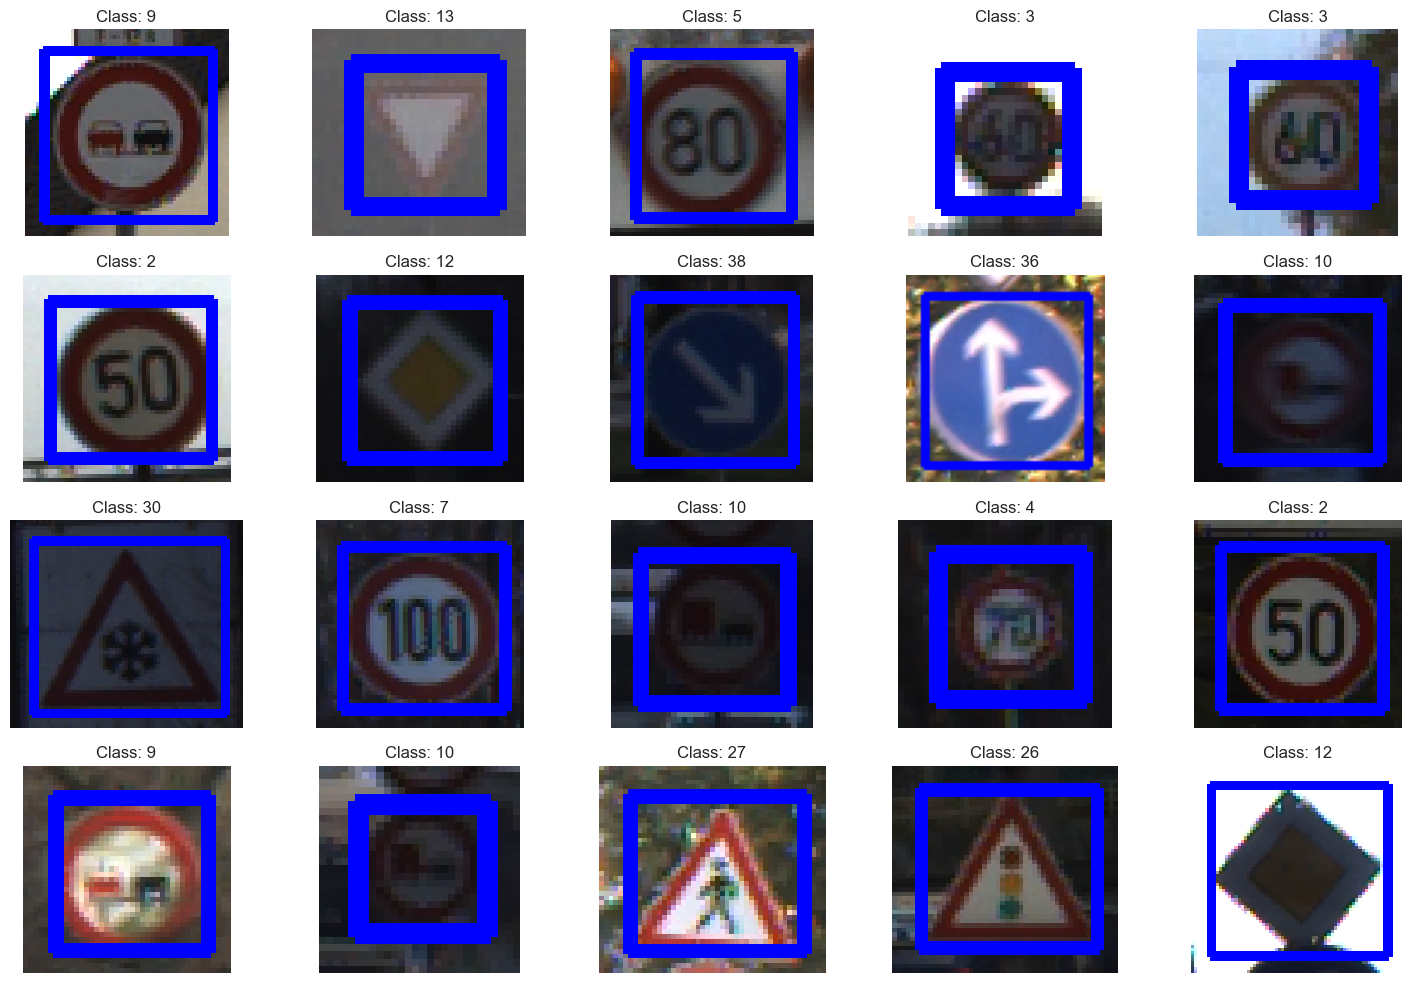

In [20]:
plot_sample_with_roi(df, dataset_path)

# 2. Подготовка данных

In [21]:
class TrafficSignsDataset(Dataset):
    def __init__(self, df, dataset_path, transform=None, device='cuda'):
        self.df = df
        self.dataset_path = dataset_path
        self.transform = transform
        self.device = device
        
        self.images = []
        self.labels = []

        for _, row in df.iterrows():
            img_path = os.path.join(self.dataset_path, row["Path"])
            try:
                image = Image.open(img_path).convert("RGB")
            except FileNotFoundError:
                print(f"Image not found at: {img_path}")
                continue

            if self.transform:
                image = self.transform(image)

            self.images.append(image)
            self.labels.append(row["ClassId"])

        self.images = torch.stack([image.clone().detach() for image in self.images]).to(self.device)
        self.labels = torch.tensor(self.labels, dtype=torch.long).to(self.device)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Получаем изображение и метку по индексу
        image = self.images[idx]
        label = self.labels[idx]

        return image, label

# 2.1. Аугментации

In [22]:
def calculate_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    mean = 0.0
    std = 0.0
    total_images = 0

    for images, _ in loader:
        batch_samples = images.size(0) 
        total_images += batch_samples
        mean += images.mean(dim=(0, 2, 3)) * batch_samples
        std += images.std(dim=(0, 2, 3)) * batch_samples

    mean /= total_images
    std /= total_images
    return mean, std

In [23]:
transform_temp = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [24]:
temp_dataset_train = TrafficSignsDataset(df, dataset_path, transform=transform_temp)
temp_dataset_test = TrafficSignsDataset(df_test, dataset_path, transform=transform_temp)

In [ ]:
mean_train, std_train = calculate_mean_std(temp_dataset_train)

print(f"Mean train: {mean_train.numpy()}")
print(f"Std train: {std_train.numpy()}")

In [25]:
# mean_test, std_test = calculate_mean_std(temp_dataset_test)

# print(f"Mean test: {mean_test.numpy()}")
# print(f"Std test: {std_test.numpy()}")

In [26]:
# transform_train = transforms.Compose([
#     transforms.Resize((32, 32)), 
#     transforms.RandomRotation(10),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),     
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
#     transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),  
#     transforms.GaussianBlur(kernel_size=3), 
#     transforms.ToTensor(),
#     transforms.Normalize((0.34025788, 0.3121442, 0.32143834), (0.21588029, 0.2116964, 0.22027877)) 
# ])

In [216]:
transform_train = transforms.Compose([
    transforms.Resize((32, 32)), 
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),  
    transforms.GaussianBlur(kernel_size=3), 
    transforms.ToTensor(),  
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3)),  
    transforms.Normalize((0.34025788, 0.3121442, 0.32143834), (0.21588029, 0.2116964, 0.22027877)) 
])

In [217]:
# transform_train = transforms.Compose([
#     transforms.Resize((32, 32)), 
#     transforms.RandomApply([transforms.RandomRotation(13)], p=0.5),  
#     transforms.RandomApply([transforms.RandomAffine(
#         degrees=10, translate=(0.2, 0.2), scale=(0.8, 1.2))], p=0.5),  
#     transforms.RandomApply([transforms.ColorJitter(
#         brightness=0.4, contrast=0.4, saturation=0.4)], p=0.5), 
#     transforms.RandomApply([transforms.RandomResizedCrop(32, scale=(0.7, 1.0))], p=0.5), 
#     transforms.RandomApply([transforms.GaussianBlur(kernel_size=(3, 3))], p=0.5), 
#     transforms.ToTensor(),  
#     transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.0)), 
#     transforms.Normalize((0.34025788, 0.3121442, 0.32143834), 
#                          (0.21588029, 0.2116964, 0.22027877))  
# ])

####  Описание и обоснование применяемых аугментаций


#### 1. `transforms.RandomRotation(10)`

**Описание:** Поворачивает изображение на случайный угол в диапазоне ±10°.

**Обоснование:** В реальных условиях дорожные знаки могут быть расположены под небольшим углом относительно камеры (например, на поворотах дорог). Эта аугментация повышает устойчивость модели к таким поворотам.


#### 2. `transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1))`

**Описание:** Применяет случайные преобразования переноса (до 10% от размеров изображения) и масштабирования (от 90% до 110%).

**Обоснование:** Позволяет имитировать ситуации, когда знаки расположены на разном расстоянии или не идеально центрированы в кадре.


#### 3. `transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)`

**Описание:** Изменяет яркость, контраст и насыщенность изображения.

**Обоснование:** Учитывает вариации в освещении (например, тень от деревьев, разные погодные условия) и качество камеры. Повышает устойчивость модели к изменениям цвета изображения.


#### 4. `transforms.RandomResizedCrop(32, scale=(0.8, 1.0))`

**Описание:** Случайным образом обрезает изображение и масштабирует его до 32x32 пикселей.

**Обоснование:** Имитирует случаи, когда знак не полностью виден в кадре, и увеличивает разнообразие изображений в тренировочной выборке.


#### 5. `transforms.GaussianBlur(kernel_size=3)`

**Описание:** Применяет размытие изображения с помощью гауссова фильтра.

**Обоснование:** Имитирует ситуации, когда изображение может быть нечетким из-за движения камеры или других факторов (например, грязь на объективе).


#### 6. `transforms.RandomPerspective(distortion_scale=0.2, p=0.5)`

**Описание:** Применяет перспективные искажения с вероятностью 50%.

**Обоснование:** Учитывает изменения, вызванные углом съемки относительно поверхности дорожного знака (например, наклон или смещение камеры).


#### 7. `transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3))`

**Описание:** Стирает случайную область изображения с вероятностью 50%.

**Обоснование:** Имитирует частичное перекрытие знака (например, листьями, грязью или другими объектами). Улучшает устойчивость модели к таким ситуациям.


In [218]:
transform_test = transforms.Compose([
    transforms.Resize((32, 32)), 
    transforms.ToTensor(),  
    transforms.Normalize((0.34025788, 0.3121442, 0.32143834), (0.21588029, 0.2116964, 0.22027877)) 
])

In [219]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [220]:
train_dataset = TrafficSignsDataset(df, dataset_path, transform=transform_train)

In [221]:
test_dataset = TrafficSignsDataset(
    df=df_test,  
    dataset_path=dataset_path,  
    transform=transform_test 
)

## 2.2. Устранение дисбаланса классов при помощи WeightedRandomSampler 

In [222]:
# Рассчитываем веса для классов
max_count = class_counts.max()
class_weights = {cls: max_count / count for cls, count in class_counts.items()}
df["weight"] = df["ClassId"].map(class_weights)
weights = df["weight"].values

In [223]:
class_weights

{0: 10.714285714285714,
 1: 1.0135135135135136,
 2: 1.0,
 3: 1.5957446808510638,
 4: 1.1363636363636365,
 5: 1.2096774193548387,
 6: 5.357142857142857,
 7: 1.5625,
 8: 1.5957446808510638,
 9: 1.530612244897959,
 10: 1.1194029850746268,
 11: 1.7045454545454546,
 12: 1.0714285714285714,
 13: 1.0416666666666667,
 14: 2.8846153846153846,
 15: 3.5714285714285716,
 16: 5.357142857142857,
 17: 2.027027027027027,
 18: 1.875,
 19: 10.714285714285714,
 20: 6.25,
 21: 6.818181818181818,
 22: 5.769230769230769,
 23: 4.411764705882353,
 24: 8.333333333333334,
 25: 1.5,
 26: 3.75,
 27: 9.375,
 28: 4.166666666666667,
 29: 8.333333333333334,
 30: 5.0,
 31: 2.8846153846153846,
 32: 9.375,
 33: 3.265602322206096,
 34: 5.357142857142857,
 35: 1.875,
 36: 5.769230769230769,
 37: 10.714285714285714,
 38: 1.0869565217391304,
 39: 7.5,
 40: 6.25,
 41: 9.375,
 42: 9.375}

In [224]:
weights

array([6.25 , 6.25 , 6.25 , ..., 9.375, 9.375, 9.375])

In [225]:
sampler = WeightedRandomSampler(weights, num_samples=len(train_dataset), replacement=True)

In [226]:
train_loader = DataLoader(train_dataset, batch_size=640, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=640, shuffle=False)

In [227]:
# Проверка формирования батча
for images, labels in train_loader:
    print("Размер батча:", images.shape)
    print("Метки классов в батче:", labels.cpu().numpy())
    break

Размер батча: torch.Size([640, 3, 32, 32])
Метки классов в батче: [ 8  3 11 17 19  5 15  6 10 14 18 37 12 16 15 34 10  7 21 21 19 35  7  0
 27 37 26 16  3 27 30  7 31 23 34 35 14  8  2 28 24 19 33 37 35 22 42 12
 29 33 36  5 26 34 18 30  6 35 40  2 41 18  9 33 19 30 23  1 18  7 39 28
 24 17 13 23 15 13 15 40  7 22  4  6 41 31 21 38 25  1 40 16 41 31  7 12
 20 30 16  5  1 32 15 16  8 10  4 10 18 35  6  2 27 35 28 23  1 11 17 32
 11 33 22 10 19 10  4 17 40  6 24 32  7 38 24 20 35 31 28 20  4 11 28 35
 26  8 13 17 14 24 34 32 31  1 19  2 20  3 39 40 28 16  9 36  2 37 14 23
 35 35  2 31 14 22  0 22 19  0 34 19  7 13 10 40  6 20 17 10 34 27 17 21
 15  4 38  1  6 15 14 13 38 18  5  8 19 27 17 19  0 13 21 27  8 10 31 28
 36 25 42 31 15 26 26  9  6 41 37 19 20 40 11 21 32 21 37 38 37 40 20 37
 14 29 36 36 13 23 25 37 36 11 38 14  0 11 21 15  4 28  7 27 36 30 23 30
 39 12  6 31 27 14 30 27  2 13 27 21 38 36 22 41 19 10 23 28 16 35 23 31
 14 40  8 37  9 25 26 14 35 10  6 36 11 20 31 31 31 18  7 

In [228]:
for images, labels in test_loader:
    print("Размер батча:", images.shape)
    print("Метки классов в батче:", labels.cpu().numpy())
    break 

Размер батча: torch.Size([640, 3, 32, 32])
Метки классов в батче: [16  1 38 33 11 38 18 12 25 35 12  7 23  7  4  9 21 20 27 38  4 33  9  3
  1 11 13 10  9 11  5 17 34 23  2 17  3 12 16  8  7 30 18 12 24 25  3 10
 18  8 25 13 15  9 13 35  5 26  9 16 38 10  4  9 15  9 26  2  5 28 11 25
 30 34  5 12  1 10 25 25 21 33 25  7 10 35  3  7 22 13  3  1  2 14 12 32
  3 38  9 33  1 10  5 11 33  4 35 25 33  4  1 14 16 10 30  3 27 29  1 17
 13  7  1  8  2 10 10 30  1  6 36  3 14 13 11 10 18 40  2 38 41  4  6 18
 17 25  2 41 11 21  7 24 11 25 17  3  6  9  7  4 13 16  4 25 18  9 13 14
 29 17 13 38 26 25 33  1  3 40 13  2  8  4 36 25 20 25 18  1 10  8 10 29
 12 38 31  2  8 38 18 28 17  9  4  1 17  9  2 31 13 15 15 38 25  5 25 13
 10  5  4 10  2  4  5  1 14 12 12  5  8 36 25 13 33 18 33 19 12 30  4 18
 12 13 20  0 10 40  5  8 12 38 20 14  0 36 34 28 35 13 25 15 35 14 18 25
  1 12  5 25  2 18 18 18 34  9 25 18 34 39 31  1  9 35 31 26  1  1 33 30
 17 13  1 31 13 35  5  1 33 28 35 26 12  5  2 14  4  3 32 

# 3. Тренировка модели (усовершенствованный Le-Net-5) 

    В модель мною были внесены следующие изменения и модификации:


 - Добавление Batch Normalization : Batch Normalization стабилизирует обучение, ускоряет сходимость и может улучшить итоговую точность

 - Замена Adam на AdamW: AdamW (Adam with Weight Decay) улучшает обучение, особенно для моделей с большим количеством параметров, за счёт более корректной реализации регуляризации через weight decay.

 - Добавление аугментаций: Аугментации увеличивают разнообразие данных и помогают модели обобщать лучше. Примеры аугментаций: флипы, повороты, изменения яркости, контраста и т.д.

 - Использование MaxPooling: MaxPooling обычно лучше для выделения ключевых признаков, так как оно берёт максимум в окне, что снижает вероятность пропуска важных признаков.

 - Использование Cyclic Learning Rate (CLR): CLR — это метод адаптивного изменения learning rate (LR) в циклической форме (периодически увеличивается и уменьшается). Это помогает модели избегать застревания в локальных минимумах и находить лучшее значение LR

In [377]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=43):
        super(LeNet5, self).__init__()

        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(6)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1, padding=0)  
        self.bn3 = nn.BatchNorm2d(120)
        
        self.fc1 = nn.Linear(120, 84)  
        self.dropout1 = nn.Dropout(p=0.5)
        
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1) 
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)

        return x

    def fit(self, train_loader, val_loader, num_epochs, base_lr=0.0001, max_lr=0.01, step_size_down=2000):
        
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(self.parameters(), lr=0.001, weight_decay=1e-3)
        
        scheduler = CyclicLR(
        optimizer,
        base_lr=base_lr,
        max_lr=max_lr,
        step_size_down=step_size_down,
        mode='triangular2'
        )

        train_losses = []
        val_losses = []
        lr_history = []

        start_time = time.time()  
        for epoch in range(num_epochs):
            self.train() 
            epoch_loss = 0.0
            for batch_idx, (images, labels) in enumerate(train_loader):
                images, labels = images.to(device), labels.to(device) 
                
                optimizer.zero_grad() 
                outputs = self(images) 
                loss = criterion(outputs, labels)  
                loss.backward()  
                optimizer.step() 
                scheduler.step()  
                lr_history.append(optimizer.param_groups[0]['lr'])
            
                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_epoch_loss)
            print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_epoch_loss:.4f}')

            self.eval()  
            val_epoch_loss = 0.0
            with torch.no_grad(): 
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)  
                    outputs = self(images) 
                    loss = criterion(outputs, labels)
                    val_epoch_loss += loss.item()

            avg_val_loss = val_epoch_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f'Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}\n')

        total_time = time.time() - start_time
        print(f'Total fitting time: {total_time:.2f} seconds')

        self.plot_losses(train_losses, val_losses)
        self.plot_learning_rate(lr_history)

        return train_losses, val_losses

    def evaluate(self, test_loader):

        self.eval()  
        all_labels = [] 
        all_predictions = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)  
                outputs = self(images)
                _, predicted = torch.max(outputs.data, 1)
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        balanced_acc = balanced_accuracy_score(all_labels, all_predictions)
        print(f'Balanced Accuracy: {balanced_acc * 100:.2f}%')

        report = classification_report(all_labels, all_predictions, digits=4)
        print(report)

        cm = confusion_matrix(all_labels, all_predictions)
        self.confusion_matrix_visualisation(cm)
        
    def plot_losses(self, train_losses, val_losses):

        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss', color='blue')
        plt.plot(val_losses, label='Validation Loss', color='orange')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.legend()
        plt.grid()
        plt.show()
        
    def plot_learning_rate(self, lr_history):
        plt.figure(figsize=(10, 5))
        plt.plot(lr_history, label='Learning Rate', color='green')
        plt.xlabel('Iterations')
        plt.ylabel('Learning Rate')
        plt.title('Learning Rate Scheduler')
        plt.legend()
        plt.grid()
        plt.show()

    def confusion_matrix_visualisation(self, cm):

        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, square=True, annot=True, cmap='BuPu', fmt='d', annot_kws={"size": 8}) 
        plt.title('Confusion Matrix')
        plt.ylabel('Actual Class')
        plt.xlabel('Predicted Class')
        plt.tight_layout()
        plt.show()

In [378]:
model = LeNet5(num_classes=43).to(device)

In [379]:
next(model.parameters()).is_cuda

True

Epoch [1/90], Training Loss: 3.7049
Epoch [1/90], Validation Loss: 3.5588

Epoch [2/90], Training Loss: 3.4101
Epoch [2/90], Validation Loss: 3.1127

Epoch [3/90], Training Loss: 2.9476
Epoch [3/90], Validation Loss: 2.4094

Epoch [4/90], Training Loss: 2.4499
Epoch [4/90], Validation Loss: 1.8803

Epoch [5/90], Training Loss: 2.1118
Epoch [5/90], Validation Loss: 1.5868

Epoch [6/90], Training Loss: 1.8425
Epoch [6/90], Validation Loss: 1.3722

Epoch [7/90], Training Loss: 1.6601
Epoch [7/90], Validation Loss: 1.2401

Epoch [8/90], Training Loss: 1.4992
Epoch [8/90], Validation Loss: 1.2428

Epoch [9/90], Training Loss: 1.3852
Epoch [9/90], Validation Loss: 1.1013

Epoch [10/90], Training Loss: 1.2635
Epoch [10/90], Validation Loss: 1.0268

Epoch [11/90], Training Loss: 1.1790
Epoch [11/90], Validation Loss: 0.9973

Epoch [12/90], Training Loss: 1.0765
Epoch [12/90], Validation Loss: 0.9664

Epoch [13/90], Training Loss: 1.0152
Epoch [13/90], Validation Loss: 0.9626

Epoch [14/90], Tr

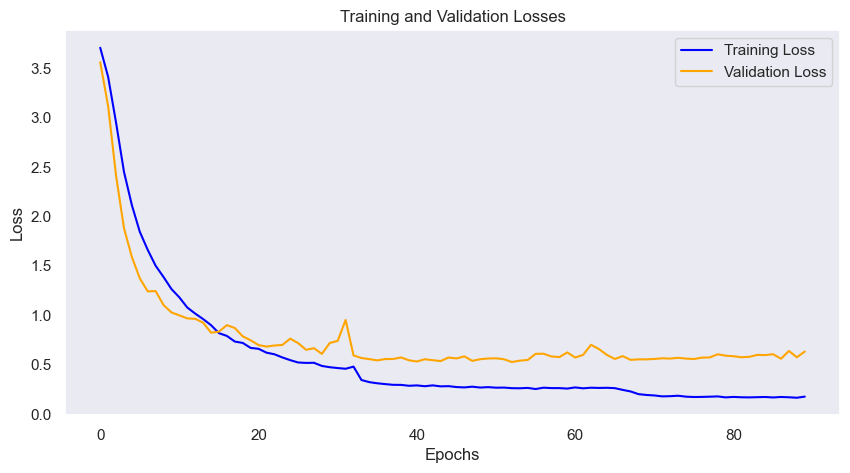

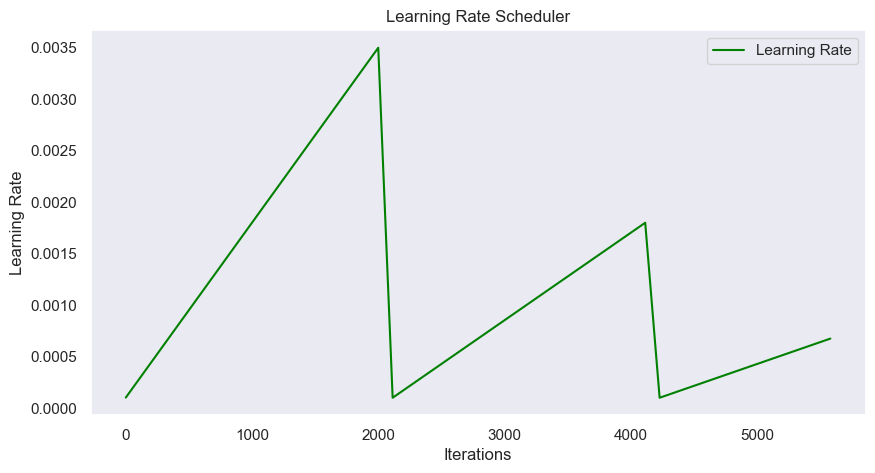

Total fitting time: 58.63 seconds


In [380]:
num_epochs = 90

start_time = time.time()
train_losses, val_losses = model.fit(train_loader, test_loader, num_epochs, base_lr=0.0001, max_lr=0.0035, step_size_down=114)
total_time = time.time() - start_time
print(f'Total fitting time: {total_time:.2f} seconds')

Balanced Accuracy: 83.32%
              precision    recall  f1-score   support

           0     0.8571    0.3000    0.4444        60
           1     0.8205    0.8000    0.8101       720
           2     0.7747    0.7933    0.7839       750
           3     0.8775    0.8756    0.8765       450
           4     0.7637    0.7394    0.7513       660
           5     0.7856    0.6571    0.7156       630
           6     0.9630    0.8667    0.9123       150
           7     0.7293    0.7844    0.7559       450
           8     0.6813    0.9311    0.7869       450
           9     0.9782    0.9354    0.9563       480
          10     0.9953    0.9712    0.9831       660
          11     0.8913    0.8976    0.8944       420
          12     0.9984    0.9304    0.9632       690
          13     0.9742    0.9958    0.9849       720
          14     0.9747    1.0000    0.9872       270
          15     0.9286    0.9286    0.9286       210
          16     0.9304    0.9800    0.9545       150
 

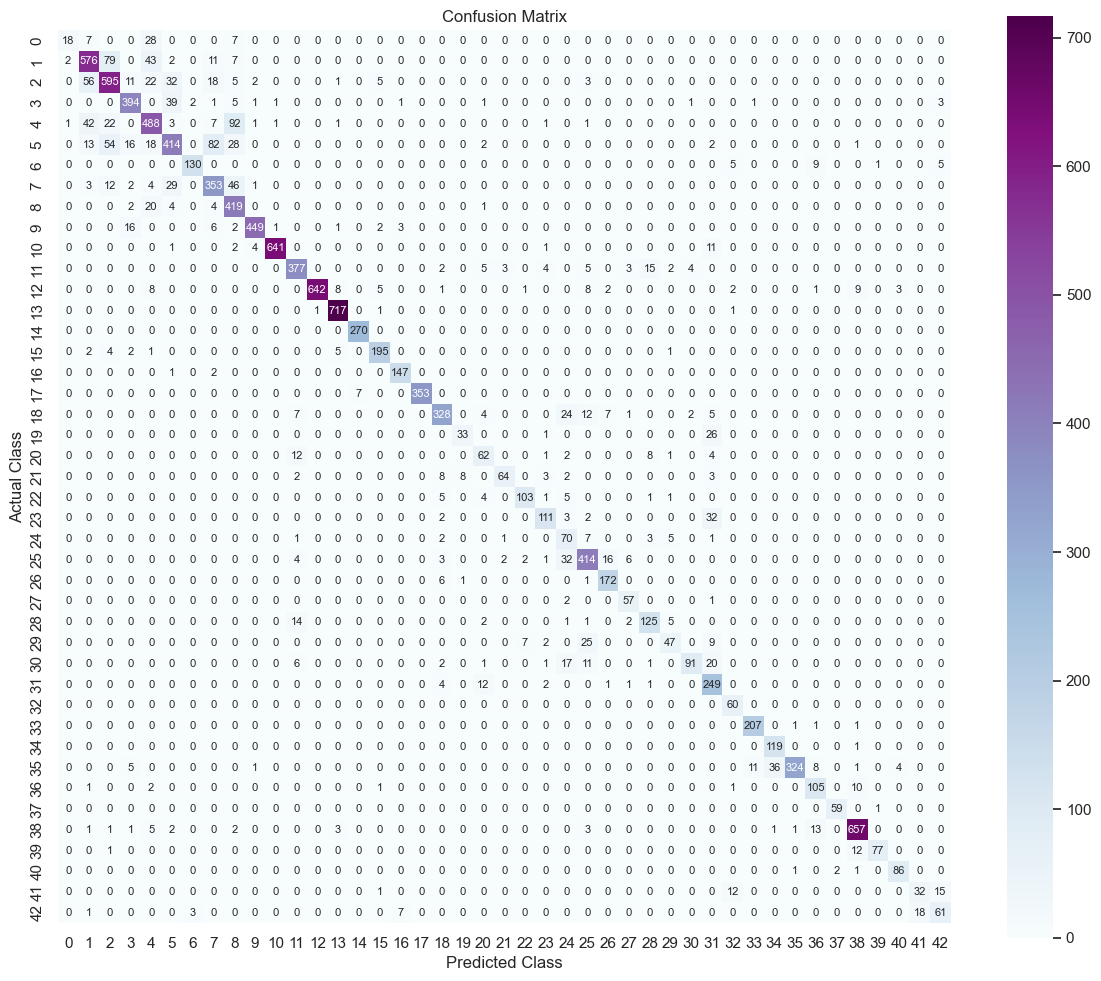

In [381]:
model.evaluate(test_loader)

# 3_upd. Сильно модифицированная и изменённая модель, уже не LeNet-5

In [287]:
class CustomModel(nn.Module):
    def __init__(self, num_classes=43):
        super(CustomModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=0)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(512, 256)
        self.dropout1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(p=0.5)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.relu(self.bn4(self.conv4(x)))

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)  # Без активации softmax

        return x

    def fit(self, train_loader, val_loader, num_epochs, base_lr=0.0001, max_lr=0.01, step_size_up=200):

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(self.parameters(), lr=0.001, weight_decay=1e-1)
        scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=base_lr, max_lr=max_lr, step_size_up=step_size_up, mode='triangular2')

        train_losses, val_losses = [], []
        lr_history = [] 
        for epoch in range(num_epochs):
            self.train()
            epoch_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)  
                optimizer.zero_grad()
                outputs = self(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                scheduler.step()
                
                lr_history.append(optimizer.param_groups[0]['lr'])

                epoch_loss += loss.item()

            train_losses.append(epoch_loss / len(train_loader))
            print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {train_losses[-1]:.4f}")

            self.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device) 
                    outputs = self(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

            val_losses.append(val_loss / len(val_loader))
            print(f"Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {val_losses[-1]:.4f}")

        self.plot_losses(train_losses, val_losses)
        self.plot_learning_rate(lr_history) 

        return train_losses, val_losses

    def evaluate(self, test_loader):
        
        self.eval()  
        all_labels = [] 
        all_predictions = [] 

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device) 
                outputs = self(images)
                _, predicted = torch.max(outputs.data, 1)
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        balanced_acc = balanced_accuracy_score(all_labels, all_predictions)
        print(f'Balanced Accuracy: {balanced_acc * 100:.2f}%')

        report = classification_report(all_labels, all_predictions, digits=4)
        print(report)

        cm = confusion_matrix(all_labels, all_predictions)
        self.confusion_matrix_visualisation(cm)

    def plot_losses(self, train_losses, val_losses):
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss', color='blue')
        plt.plot(val_losses, label='Validation Loss', color='orange')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.legend()
        plt.grid()
        plt.show()

    def plot_learning_rate(self, lr_history):
        plt.figure(figsize=(10, 5))
        plt.plot(lr_history, label='Learning Rate', color='green')
        plt.xlabel('Iterations')
        plt.ylabel('Learning Rate')
        plt.title('Learning Rate Scheduler')
        plt.legend()
        plt.grid()
        plt.show()

    def confusion_matrix_visualisation(self, cm):
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, square=True, annot=True, cmap='BuPu', fmt='d', annot_kws={"size": 8}) 
        plt.title('Confusion Matrix')
        plt.ylabel('Actual Class')
        plt.xlabel('Predicted Class')
        plt.tight_layout()
        plt.show()

In [288]:
model2 = CustomModel(num_classes=43).to(device)

Epoch [1/40], Training Loss: 3.2990
Epoch [1/40], Validation Loss: 2.9387
Epoch [2/40], Training Loss: 2.5604
Epoch [2/40], Validation Loss: 2.7864
Epoch [3/40], Training Loss: 2.3948
Epoch [3/40], Validation Loss: 3.3292
Epoch [4/40], Training Loss: 2.0208
Epoch [4/40], Validation Loss: 1.7409
Epoch [5/40], Training Loss: 1.4091
Epoch [5/40], Validation Loss: 1.2674
Epoch [6/40], Training Loss: 1.0215
Epoch [6/40], Validation Loss: 0.8785
Epoch [7/40], Training Loss: 0.8040
Epoch [7/40], Validation Loss: 0.7636
Epoch [8/40], Training Loss: 0.7630
Epoch [8/40], Validation Loss: 0.7851
Epoch [9/40], Training Loss: 0.7335
Epoch [9/40], Validation Loss: 0.8077
Epoch [10/40], Training Loss: 0.6429
Epoch [10/40], Validation Loss: 0.7639
Epoch [11/40], Training Loss: 0.4660
Epoch [11/40], Validation Loss: 0.5495
Epoch [12/40], Training Loss: 0.3443
Epoch [12/40], Validation Loss: 0.5391
Epoch [13/40], Training Loss: 0.2573
Epoch [13/40], Validation Loss: 0.4659
Epoch [14/40], Training Loss: 

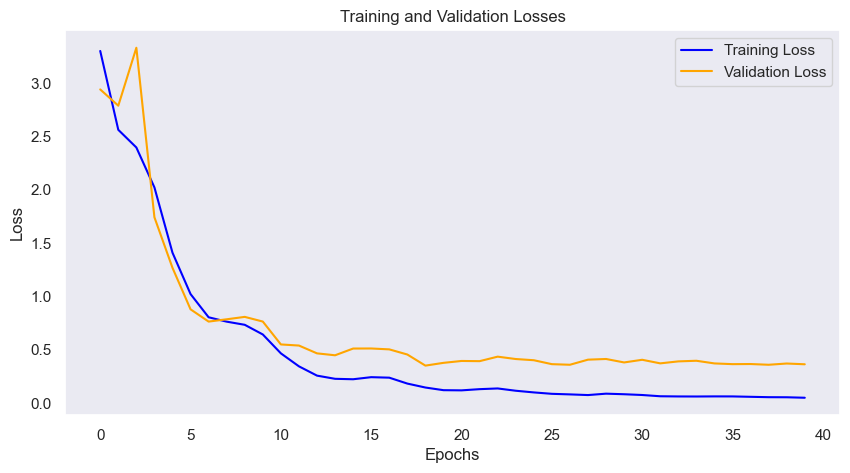

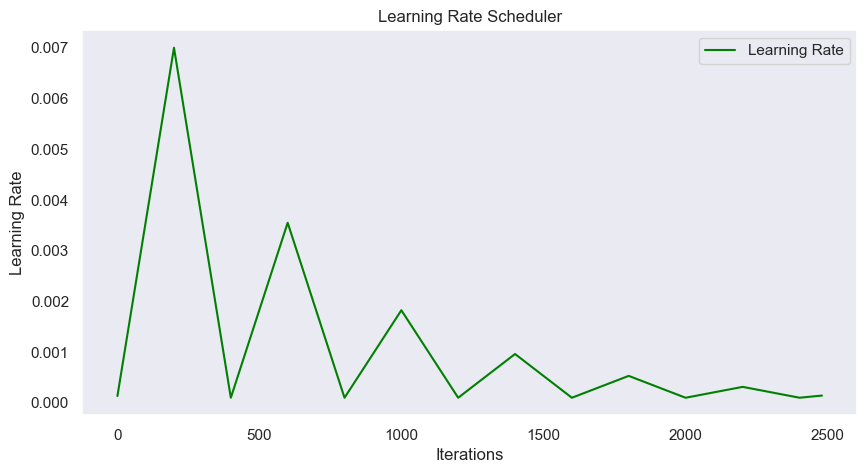

Total fitting time: 62.38 seconds


In [289]:
num_epochs = 40

start_time = time.time()
train_losses, val_losses = model2.fit(train_loader, test_loader, num_epochs, base_lr=0.0001, max_lr=0.007, step_size_up=200)
total_time = time.time() - start_time
print(f'Total fitting time: {total_time:.2f} seconds')

Balanced Accuracy: 91.37%
              precision    recall  f1-score   support

           0     0.8113    0.7167    0.7611        60
           1     0.9056    0.9597    0.9319       720
           2     0.9067    0.9200    0.9133       750
           3     0.9109    0.8178    0.8618       450
           4     0.9805    0.9152    0.9467       660
           5     0.8173    0.9159    0.8638       630
           6     0.9846    0.8533    0.9143       150
           7     0.9438    0.8578    0.8987       450
           8     0.9114    0.9600    0.9351       450
           9     0.9849    0.9521    0.9682       480
          10     0.9401    0.9742    0.9568       660
          11     0.9544    0.8976    0.9252       420
          12     0.9984    0.9188    0.9570       690
          13     0.9742    0.9972    0.9856       720
          14     0.9747    1.0000    0.9872       270
          15     0.8430    0.9714    0.9027       210
          16     0.9934    1.0000    0.9967       150
 

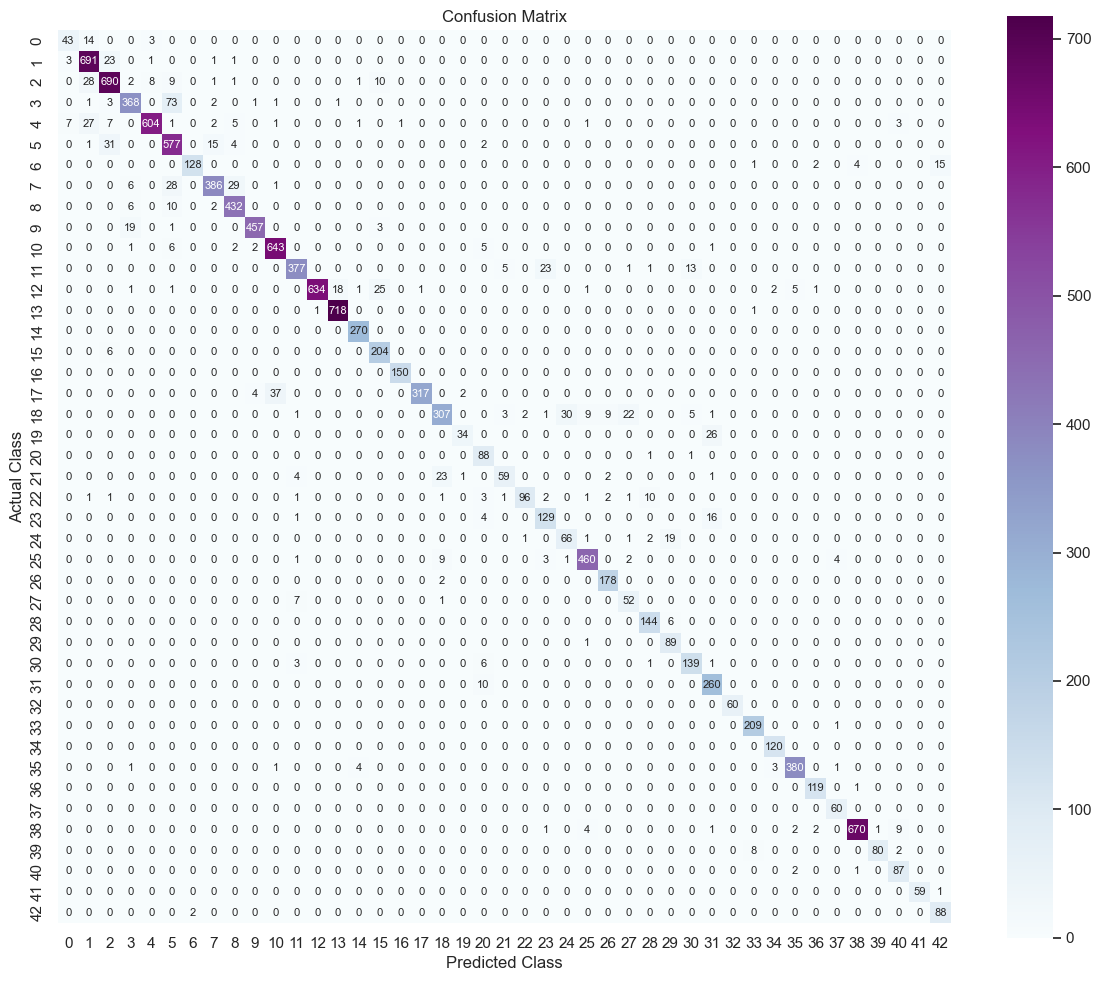

In [290]:
model2.evaluate(test_loader)

# 4. Тренировка и эсперименты с Alex-Net

In [291]:
class AlexNet32x32(nn.Module):
    def __init__(self, num_classes=43):  
        super(AlexNet32x32, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),  
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),  
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 4 * 4, 1024), 
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),  
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes) 
        )

    def forward(self, x):
        x = self.features(x)  
        x = x.view(x.size(0), -1) 
        x = self.classifier(x)  
        return x

    def fit(self, train_loader, val_loader, num_epochs, base_lr=0.0001, max_lr=0.01, step_size_up=2000, mode='triangular2'):

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(self.parameters(), lr=0.001, weight_decay=1e-3)

        scheduler = CyclicLR(
            optimizer,
            base_lr=base_lr,
            max_lr=max_lr,
            step_size_up=step_size_up,
            mode='triangular2'
        )

        train_losses = []
        val_losses = []
        learning_rates = [] 

        start_time = time.time()
        for epoch in range(num_epochs):
            self.train() 
            epoch_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = self(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                scheduler.step()

                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_epoch_loss)
            print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_epoch_loss:.4f}')

            current_lr = scheduler.get_last_lr()[0]
            learning_rates.append(current_lr)
            print(f'Learning Rate: {current_lr:.6f}')

            self.eval()  
            val_epoch_loss = 0.0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)  
                    outputs = self(images)
                    loss = criterion(outputs, labels)
                    val_epoch_loss += loss.item()

            avg_val_loss = val_epoch_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f'Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}\n')

        total_time = time.time() - start_time
        print(f'Total fitting time: {total_time:.2f} seconds')

        self.plot_losses(train_losses, val_losses)
        self.plot_learning_rate(learning_rates)
        
        return train_losses, val_losses

    def evaluate(self, test_loader):
        self.eval()  
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = self(images)
                _, predicted = torch.max(outputs.data, 1)
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        balanced_acc = balanced_accuracy_score(all_labels, all_predictions)
        print(f'Balanced Accuracy: {balanced_acc * 100:.2f}%')

        report = classification_report(all_labels, all_predictions, digits=4)
        print(report)

        cm = confusion_matrix(all_labels, all_predictions)
        self.confusion_matrix_visualisation(cm)

    def plot_losses(self, train_losses, val_losses):
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss', color='blue')
        plt.plot(val_losses, label='Validation Loss', color='orange')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.legend()
        plt.grid()
        plt.show()

    def plot_learning_rate(self, learning_rates):
        plt.figure(figsize=(10, 5))
        plt.plot(learning_rates, label='Learning Rate', color='green')
        plt.xlabel('Iterations')
        plt.ylabel('Learning Rate')
        plt.title('Learning Rate over Time')
        plt.legend()
        plt.grid()
        plt.show()

    def confusion_matrix_visualisation(self, cm):
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, square=True, annot=True, cmap='BuPu', fmt='d', annot_kws={"size": 8})
        plt.title('Confusion Matrix')
        plt.ylabel('Actual Class')
        plt.xlabel('Predicted Class')
        plt.tight_layout()
        plt.show()

In [259]:
model3 = AlexNet32x32(num_classes=43).to(device)
print(model3)

AlexNet32x32(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Max

Epoch [1/30], Training Loss: 0.1763
Learning Rate: 0.001887
Epoch [1/30], Validation Loss: 0.5076

Epoch [2/30], Training Loss: 0.3253
Learning Rate: 0.003674
Epoch [2/30], Validation Loss: 0.9560

Epoch [3/30], Training Loss: 0.4286
Learning Rate: 0.004539
Epoch [3/30], Validation Loss: 0.6360

Epoch [4/30], Training Loss: 0.2378
Learning Rate: 0.002752
Epoch [4/30], Validation Loss: 0.2553

Epoch [5/30], Training Loss: 0.1088
Learning Rate: 0.000965
Epoch [5/30], Validation Loss: 0.2615

Epoch [6/30], Training Loss: 0.0704
Learning Rate: 0.000561
Epoch [6/30], Validation Loss: 0.2712

Epoch [7/30], Training Loss: 0.0622
Learning Rate: 0.001455
Epoch [7/30], Validation Loss: 0.2788

Epoch [8/30], Training Loss: 0.0722
Learning Rate: 0.002348
Epoch [8/30], Validation Loss: 0.2170

Epoch [9/30], Training Loss: 0.0931
Learning Rate: 0.001858
Epoch [9/30], Validation Loss: 0.2046

Epoch [10/30], Training Loss: 0.0702
Learning Rate: 0.000965
Epoch [10/30], Validation Loss: 0.2256

Epoch [1

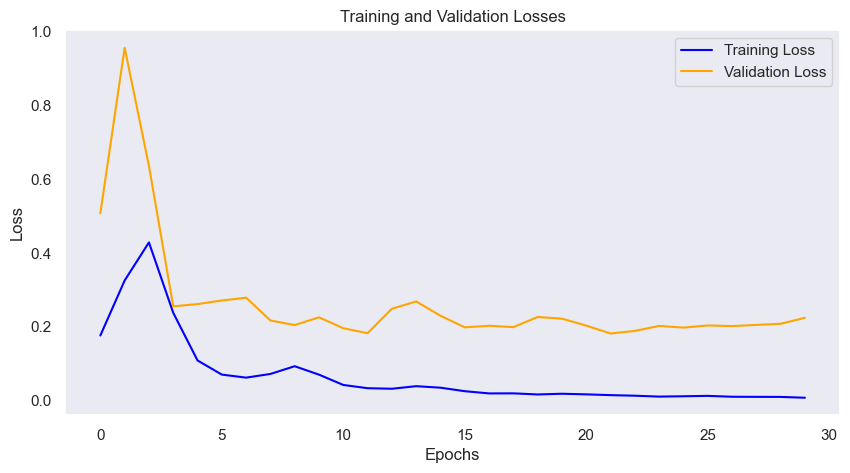

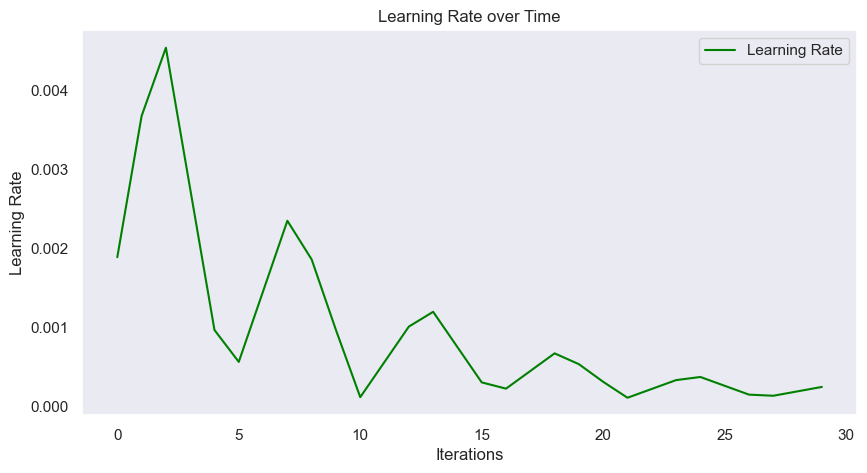

Total fitting time: 83.43 seconds


In [292]:
num_epochs = 30

start_time = time.time()
train_losses, val_losses = model3.fit(train_loader, test_loader, num_epochs, base_lr=0.0001, max_lr=0.005, step_size_up=170)
total_time = time.time() - start_time
print(f'Total fitting time: {total_time:.2f} seconds')

Balanced Accuracy: 95.68%
              precision    recall  f1-score   support

           0     0.9516    0.9833    0.9672        60
           1     0.9387    0.9778    0.9578       720
           2     0.9392    0.9680    0.9534       750
           3     0.9756    0.9756    0.9756       450
           4     0.9936    0.9439    0.9681       660
           5     0.9635    0.9222    0.9424       630
           6     0.9250    0.9867    0.9548       150
           7     0.9608    0.9267    0.9434       450
           8     0.9271    0.9889    0.9570       450
           9     0.9877    1.0000    0.9938       480
          10     0.9851    0.9985    0.9917       660
          11     0.9850    0.9381    0.9610       420
          12     1.0000    0.9406    0.9694       690
          13     0.9849    0.9972    0.9910       720
          14     1.0000    1.0000    1.0000       270
          15     1.0000    0.9952    0.9976       210
          16     1.0000    1.0000    1.0000       150
 

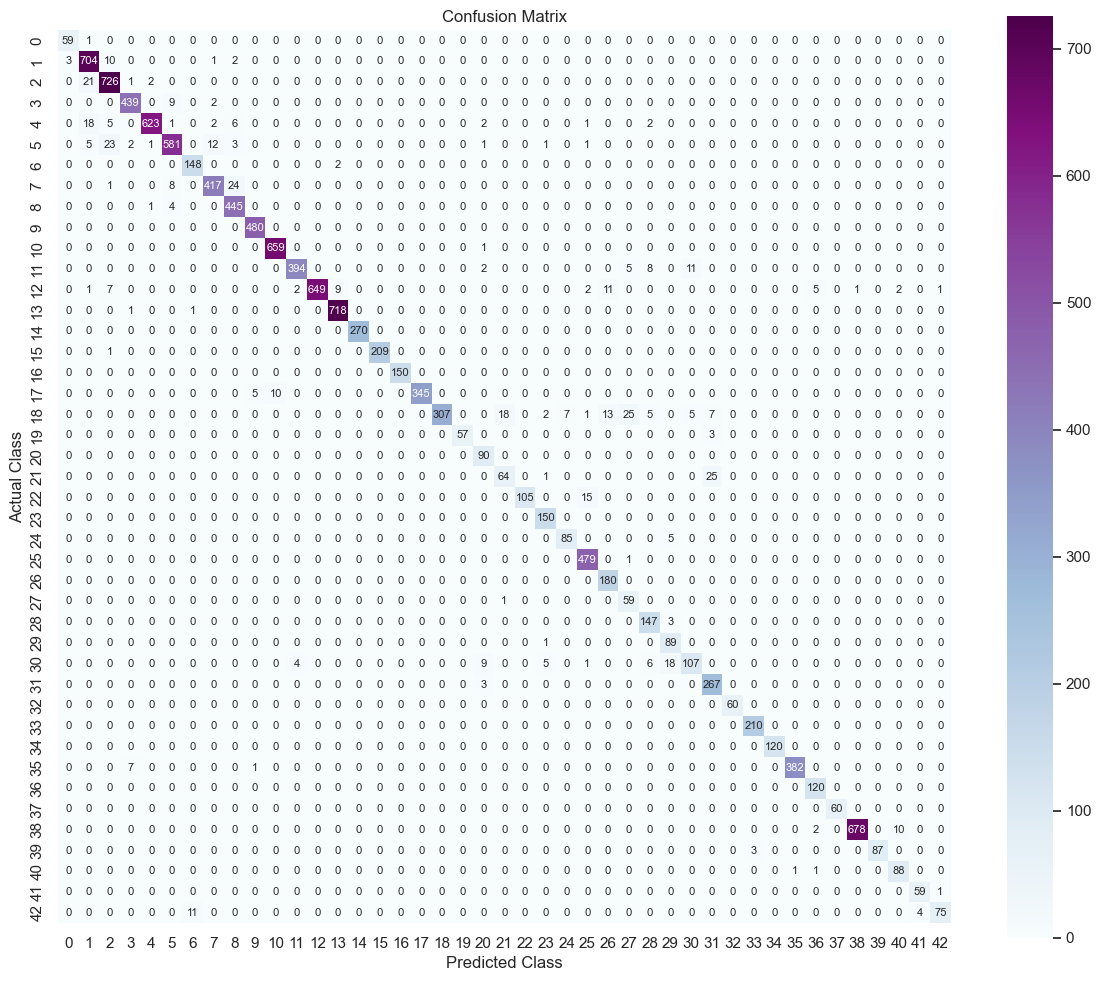

In [293]:
model3.evaluate(test_loader)